In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [4]:
#Lectura en google colab
from google.colab import files
uploaded = files.upload()
uploaded.keys()

Saving M3P1_Metodos_Reduccion.zip to M3P1_Metodos_Reduccion (1).zip


dict_keys(['M3P1_Metodos_Reduccion (1).zip'])

In [5]:
import zipfile
 # toma el primer archivo subido
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
   # lista los archivos dentro del ZIP
    print(z.namelist())


['iter_00_cpv2020/catalogos/', 'iter_00_cpv2020/catalogos/tam_loc.csv.csv', 'iter_00_cpv2020/conjunto_de_datos/', 'iter_00_cpv2020/conjunto_de_datos/conjunto_de_datos_iter_00CSV20.csv', 'iter_00_cpv2020/diccionario_datos/', 'iter_00_cpv2020/diccionario_datos/diccionario_datos_iter_00CSV20.csv', 'iter_00_cpv2020/metadatos/', 'iter_00_cpv2020/metadatos/metadatos_iter_00_cpv2020.txt']


In [8]:
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall()    # extrae en el directorio actual

In [17]:
df = pd.read_csv("iter_00_cpv2020/conjunto_de_datos/conjunto_de_datos_iter_00CSV20.csv", low_memory=False, encoding="utf-8")
print("Shape original:", df.shape)

Shape original: (195662, 286)


In [18]:
print("\nPrimeras columnas:")
print(df.columns[:40].tolist())

print("\nPrimeras filas:")
display(df.head())


Primeras columnas:
['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 'LONGITUD', 'LATITUD', 'ALTITUD', 'POBTOT', 'POBFEM', 'POBMAS', 'P_0A2', 'P_0A2_F', 'P_0A2_M', 'P_3YMAS', 'P_3YMAS_F', 'P_3YMAS_M', 'P_5YMAS', 'P_5YMAS_F', 'P_5YMAS_M', 'P_12YMAS', 'P_12YMAS_F', 'P_12YMAS_M', 'P_15YMAS', 'P_15YMAS_F', 'P_15YMAS_M', 'P_18YMAS', 'P_18YMAS_F', 'P_18YMAS_M', 'P_3A5', 'P_3A5_F', 'P_3A5_M', 'P_6A11', 'P_6A11_F', 'P_6A11_M', 'P_8A14', 'P_8A14_F', 'P_8A14_M', 'P_12A14']

Primeras filas:


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,POBFEM,POBMAS,P_0A2,P_0A2_F,P_0A2_M,P_3YMAS,P_3YMAS_F,P_3YMAS_M,P_5YMAS,P_5YMAS_F,P_5YMAS_M,P_12YMAS,P_12YMAS_F,P_12YMAS_M,P_15YMAS,P_15YMAS_F,P_15YMAS_M,P_18YMAS,P_18YMAS_F,P_18YMAS_M,P_3A5,P_3A5_F,P_3A5_M,P_6A11,P_6A11_F,P_6A11_M,P_8A14,P_8A14_F,P_8A14_M,P_12A14,P_12A14_F,P_12A14_M,P_15A17,P_15A17_F,P_15A17_M,P_18A24,P_18A24_F,P_18A24_M,P_15A49_F,P_60YMAS,P_60YMAS_F,P_60YMAS_M,REL_H_M,POB0_14,POB15_64,POB65_MAS,P_0A4,P_0A4_F,P_0A4_M,P_5A9,P_5A9_F,P_5A9_M,P_10A14,P_10A14_F,P_10A14_M,P_15A19,P_15A19_F,P_15A19_M,P_20A24,P_20A24_F,P_20A24_M,P_25A29,P_25A29_F,P_25A29_M,P_30A34,P_30A34_F,P_30A34_M,P_35A39,P_35A39_F,P_35A39_M,P_40A44,P_40A44_F,P_40A44_M,P_45A49,P_45A49_F,P_45A49_M,P_50A54,P_50A54_F,P_50A54_M,P_55A59,P_55A59_F,P_55A59_M,P_60A64,P_60A64_F,P_60A64_M,P_65A69,P_65A69_F,P_65A69_M,P_70A74,P_70A74_F,P_70A74_M,P_75A79,P_75A79_F,P_75A79_M,P_80A84,P_80A84_F,P_80A84_M,P_85YMAS,P_85YMAS_F,P_85YMAS_M,PROM_HNV,PNACENT,PNACENT_F,PNACENT_M,PNACOE,PNACOE_F,PNACOE_M,PRES2015,PRES2015_F,PRES2015_M,PRESOE15,PRESOE15_F,PRESOE15_M,P3YM_HLI,P3YM_HLI_F,P3YM_HLI_M,P3HLINHE,P3HLINHE_F,P3HLINHE_M,P3HLI_HE,P3HLI_HE_F,P3HLI_HE_M,P5_HLI,P5_HLI_NHE,P5_HLI_HE,PHOG_IND,POB_AFRO,POB_AFRO_F,POB_AFRO_M,PCON_DISC,PCDISC_MOT,PCDISC_VIS,PCDISC_LENG,PCDISC_AUD,PCDISC_MOT2,PCDISC_MEN,PCON_LIMI,PCLIM_CSB,PCLIM_VIS,PCLIM_HACO,PCLIM_OAUD,PCLIM_MOT2,PCLIM_RE_CO,PCLIM_PMEN,PSIND_LIM,P3A5_NOA,P3A5_NOA_F,P3A5_NOA_M,P6A11_NOA,P6A11_NOAF,P6A11_NOAM,P12A14NOA,P12A14NOAF,P12A14NOAM,P15A17A,P15A17A_F,P15A17A_M,P18A24A,P18A24A_F,P18A24A_M,P8A14AN,P8A14AN_F,P8A14AN_M,P15YM_AN,P15YM_AN_F,P15YM_AN_M,P15YM_SE,P15YM_SE_F,P15YM_SE_M,P15PRI_IN,P15PRI_INF,P15PRI_INM,P15PRI_CO,P15PRI_COF,P15PRI_COM,P15SEC_IN,P15SEC_INF,P15SEC_INM,P15SEC_CO,P15SEC_COF,P15SEC_COM,P18YM_PB,P18YM_PB_F,P18YM_PB_M,GRAPROES,GRAPROES_F,GRAPROES_M,PEA,PEA_F,PEA_M,PE_INAC,PE_INAC_F,PE_INAC_M,POCUPADA,POCUPADA_F,POCUPADA_M,PDESOCUP,PDESOCUP_F,PDESOCUP_M,PSINDER,PDER_SS,PDER_IMSS,PDER_ISTE,PDER_ISTEE,PAFIL_PDOM,PDER_SEGP,PDER_IMSSB,PAFIL_IPRIV,PAFIL_OTRAI,P12YM_SOLT,P12YM_CASA,P12YM_SEPA,PCATOLICA,PRO_CRIEVA,POTRAS_REL,PSIN_RELIG,TOTHOG,HOGJEF_F,HOGJEF_M,POBHOG,PHOGJEF_F,PHOGJEF_M,VIVTOT,TVIVHAB,TVIVPAR,VIVPAR_HAB,VIVPARH_CV,TVIVPARHAB,VIVPAR_DES,VIVPAR_UT,OCUPVIVPAR,PROM_OCUP,PRO_OCUP_C,VPH_PISODT,VPH_PISOTI,VPH_1DOR,VPH_2YMASD,VPH_1CUART,VPH_2CUART,VPH_3YMASC,VPH_C_ELEC,VPH_S_ELEC,VPH_AGUADV,VPH_AEASP,VPH_AGUAFV,VPH_TINACO,VPH_CISTER,VPH_EXCSA,VPH_LETR,VPH_DRENAJ,VPH_NODREN,VPH_C_SERV,VPH_NDEAED,VPH_DSADMA,VPH_NDACMM,VPH_SNBIEN,VPH_REFRI,VPH_LAVAD,VPH_HMICRO,VPH_AUTOM,VPH_MOTO,VPH_BICI,VPH_RADIO,VPH_TV,VPH_PC,VPH_TELEF,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,0,Total nacional,0,Total nacional,0,Total nacional,NaN,NaN,NaN,126014024,64540634,61473390,5764054,2848875,2915179,119976584,61554567,58422017,115693273,59433559,56259714,100528155,51962264,48565891,93985354,48732991,45252363,87492680,45530857,41961823,6462212,3193548,3268664,12986217,6398755,6587462,15287375,7531118,7756257,6542801,3229273,3313528,6492674,3202134,3290540,14736111,7398617,7337494,33885546,15142976,8139094,7003882,95.25,31755284,83663440,10321914,10047365,4969883,5077482,10764379,5311288,5453091,10943540,5389280,5554260,10806690,5344540,5462150,10422095,5256211,5165884,9993001,5131597,4861404,9420827,4893101,4527726,9020276,4688746,4331530,8503586,4441282,4062304,7942413,4130069,3812344,7037532,3705369,3332163,5695958,3002982,2692976,4821062,2563200,2257862,3645077,1938227,1706850,2647340,1413848,1233492,1814582,966684,847898,1175364,651552,523812,1039551,605583,433968,2.09,102724322,52519974,50204348,21611963,11222300,10389663,111075594,57288776,53786818,3807844,1889986,1917858,7364645,3783447,3581198,865972,547528,318444,6423548,3198595,3224953,7177185,785361,6317027,11800247,2576213,1297617,1278596,6179890,2939986,2691338,945162,1350802,1168098,1149257,13934448,4365234,8974853,864662,2900108,673540,26

In [20]:
#Registros a nivel municipal
df["MUN"] = pd.to_numeric(df["MUN"], errors="coerce")
df["LOC"] = pd.to_numeric(df["LOC"], errors="coerce")

df_mun = df[(df["MUN"] > 0) & (df["LOC"] == 0)].copy()
print("\nShape nivel municipal:", df_mun.shape)


Shape nivel municipal: (2469, 286)


In [21]:
# 6. Revisar columnas de identificación

cols_id = [c for c in ["ENTIDAD", "NOM_ENT", "MUN", "NOM_MUN", "LOC", "NOM_LOC"] if c in df_mun.columns]
print("\nColumnas de identificación disponibles:")
print(cols_id)


Columnas de identificación disponibles:
['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC']


In [22]:
# 7. Limpieza de variables

valores_nulos_custom = ["*", "N/D", "ND", "NaN", "nan", ""]

for c in df_mun.columns:
    if df_mun[c].dtype == "object":
        df_mun[c] = df_mun[c].replace(valores_nulos_custom, np.nan)

/tmp/ipykernel_767/2161937415.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mun[c] = df_mun[c].replace(valores_nulos_custom, np.nan)


In [23]:
# Intentar convertir a numérico todo lo posible,
# excepto columnas de texto de identificación
cols_texto = ["NOM_ENT", "NOM_MUN", "NOM_LOC", "LONGITUD", "LATITUD", "ALTITUD", "TAMLOC"]
cols_texto = [c for c in cols_texto if c in df_mun.columns]

for c in df_mun.columns:
    if c not in cols_texto:
        df_mun[c] = pd.to_numeric(df_mun[c], errors="ignore")

print("\nTipos de datos:")
print(df_mun.dtypes.head(30))

/tmp/ipykernel_767/2671965159.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_mun[c] = pd.to_numeric(df_mun[c], errors="ignore")



Tipos de datos:
ENTIDAD         int64
NOM_ENT        object
MUN             int64
NOM_MUN        object
LOC             int64
NOM_LOC        object
LONGITUD      float64
LATITUD       float64
ALTITUD       float64
POBTOT          int64
POBFEM          int64
POBMAS          int64
P_0A2           int64
P_0A2_F         int64
P_0A2_M         int64
P_3YMAS         int64
P_3YMAS_F       int64
P_3YMAS_M       int64
P_5YMAS         int64
P_5YMAS_F       int64
P_5YMAS_M       int64
P_12YMAS        int64
P_12YMAS_F      int64
P_12YMAS_M      int64
P_15YMAS        int64
P_15YMAS_F      int64
P_15YMAS_M      int64
P_18YMAS        int64
P_18YMAS_F      int64
P_18YMAS_M      int64
dtype: object


In [24]:
# 8. Revisar faltantes
# ---------------------------
faltantes = df_mun.isna().sum().sort_values(ascending=False)
faltantes_pct = (df_mun.isna().mean() * 100).sort_values(ascending=False)

res_faltantes = pd.DataFrame({
    "faltantes": faltantes,
    "porcentaje": faltantes_pct
})

print("\nTop columnas con más faltantes:")
display(res_faltantes.head(20))


Top columnas con más faltantes:


,faltantes,porcentaje
LONGITUD,2469,100.0
LATITUD,2469,100.0
ALTITUD,2469,100.0
TAMLOC,2469,100.0
GRAPROES_F,0,0.0
GRAPROES,0,0.0
P18YM_PB_M,0,0.0
P18YM_PB_F,0,0.0
P18YM_PB,0,0.0
P15SEC_COM,0,0.0


In [25]:
# 9. Construcción de indicadores de marginalidad
# ---------------------------
# Nota:
# Algunas columnas pueden variar según el archivo.
# Aquí usamos las que normalmente vienen en ITER 2020.

def safe_div(num, den):
    return num / den.replace(0, np.nan)

indicadores = pd.DataFrame(index=df_mun.index)

# Educación
if {"P15YM_AN", "P_15YMAS"}.issubset(df_mun.columns):
    indicadores["analfabetismo_15mas"] = safe_div(df_mun["P15YM_AN"], df_mun["P_15YMAS"])

if {"P15YM_SE", "P_15YMAS"}.issubset(df_mun.columns):
    indicadores["sin_escolaridad_15mas"] = safe_div(df_mun["P15YM_SE"], df_mun["P_15YMAS"])

if {"P6A11_NOA", "P12A14NOA", "P_6A11", "P_12A14"}.issubset(df_mun.columns):
    indicadores["inasistencia_6_14"] = safe_div(
        df_mun["P6A11_NOA"] + df_mun["P12A14NOA"],
        df_mun["P_6A11"] + df_mun["P_12A14"]
    )

# Vivienda y servicios
if {"VPH_PISOTI", "TVIVPARHAB"}.issubset(df_mun.columns):
    indicadores["piso_tierra"] = safe_div(df_mun["VPH_PISOTI"], df_mun["TVIVPARHAB"])

if {"VPH_S_ELEC", "TVIVPARHAB"}.issubset(df_mun.columns):
    indicadores["sin_electricidad"] = safe_div(df_mun["VPH_S_ELEC"], df_mun["TVIVPARHAB"])

if {"VPH_NODREN", "TVIVPARHAB"}.issubset(df_mun.columns):
    indicadores["sin_drenaje"] = safe_div(df_mun["VPH_NODREN"], df_mun["TVIVPARHAB"])

if {"VPH_AGUAFV", "TVIVPARHAB"}.issubset(df_mun.columns):
    indicadores["agua_fuera_vivienda"] = safe_div(df_mun["VPH_AGUAFV"], df_mun["TVIVPARHAB"])

if "PRO_OCUP_C" in df_mun.columns:
    indicadores["ocupantes_por_cuarto"] = pd.to_numeric(df_mun["PRO_OCUP_C"], errors="coerce")

print("\nIndicadores construidos:")
print(indicadores.columns.tolist())

display(indicadores.head())


Indicadores construidos:
['analfabetismo_15mas', 'sin_escolaridad_15mas', 'inasistencia_6_14', 'piso_tierra', 'sin_electricidad', 'sin_drenaje', 'agua_fuera_vivienda', 'ocupantes_por_cuarto']


,analfabetismo_15mas,sin_escolaridad_15mas,inasistencia_6_14,piso_tierra,sin_electricidad,sin_drenaje,agua_fuera_vivienda,ocupantes_por_cuarto
6,0.016422,0.020603,0.046011,0.005735,0.001642,0.002991,0.003707,0.84
574,0.035234,0.034695,0.062949,0.014671,0.007575,0.035640,0.009887,1.07
749,0.044873,0.050946,0.069485,0.011193,0.007204,0.006625,0.009391,0.97
918,0.031395,0.030295,0.056976,0.010160,0.006350,0.011938,0.007874,1.14
985,0.023774,0.028343,0.058776,0.012374,0.004667,0.007798,0.008611,0.95


In [26]:
# 10. Revisar faltantes en indicadores
# ---------------------------
print("\nFaltantes por indicador:")
display(indicadores.isna().sum().to_frame("faltantes"))


Faltantes por indicador:


,faltantes
analfabetismo_15mas,0
sin_escolaridad_15mas,0
inasistencia_6_14,0
piso_tierra,0
sin_electricidad,0
sin_drenaje,0
agua_fuera_vivienda,0
ocupantes_por_cuarto,0


In [27]:
# 11. Estadísticos descriptivos
# ---------------------------
desc = indicadores.describe().T
desc["missing"] = indicadores.isna().sum()
desc["missing_pct"] = indicadores.isna().mean() * 100

print("\nEstadísticos descriptivos:")
display(desc)


Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
analfabetismo_15mas,2469.0,0.101560,0.076310,0.003526,0.044184,0.081914,0.137774,0.530573,0,0.0
sin_escolaridad_15mas,2469.0,0.094784,0.066970,0.005181,0.044328,0.078493,0.125475,0.498816,0,0.0
inasistencia_6_14,2469.0,0.063131,0.034447,0.000000,0.041716,0.057296,0.078093,0.385604,0,0.0
piso_tierra,2469.0,0.079760,0.088166,0.000000,0.017995,0.047619,0.109712,0.669786,0,0.0
sin_electricidad,2469.0,0.018400,0.028096,0.000000,0.005594,0.011777,0.021884,0.494155,0,0.0
sin_drenaje,2469.0,0.138118,0.192260,0.000000,0.022901,0.059643,0.160300,0.991004,0,0.0
agua_fuera_vivienda,2469.0,0.062384,0.090910,0.000000,0.010541,0.027071,0.074742,0.788530,0,0.0
ocupantes_por_cuarto,2469.0,1.101349,0.237727,0.530000,0.940000,1.070000,1.220000,2.280000,0,0.0


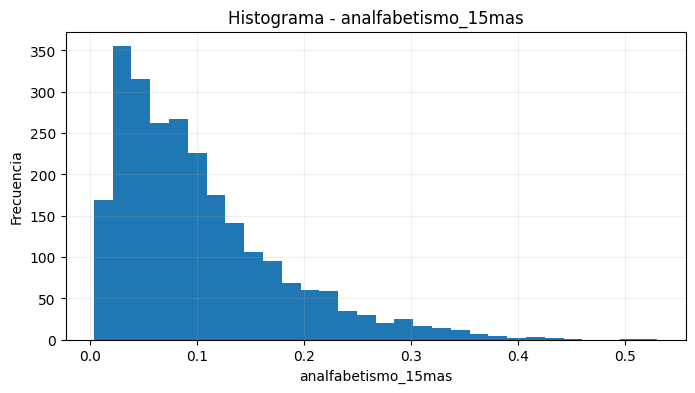

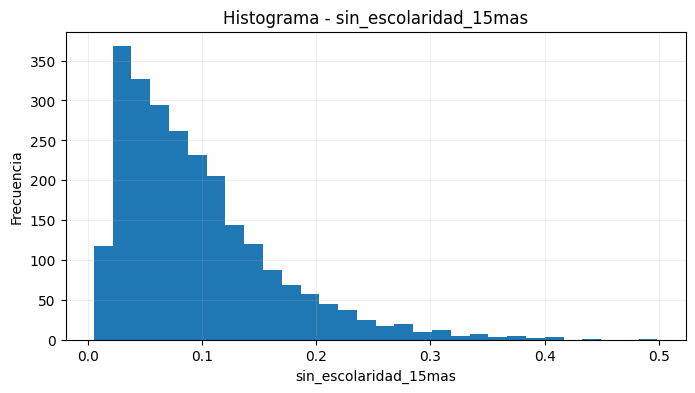

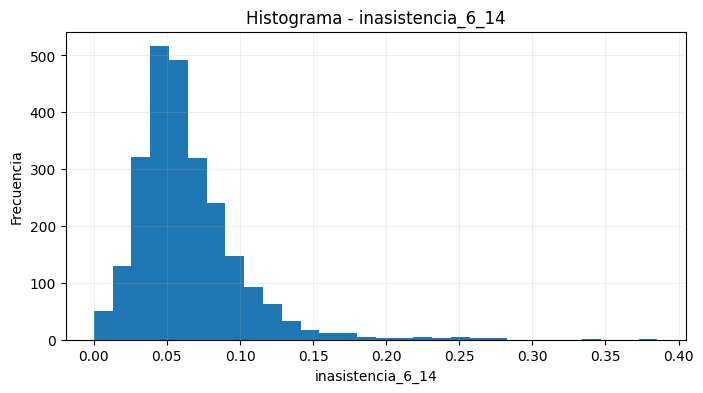

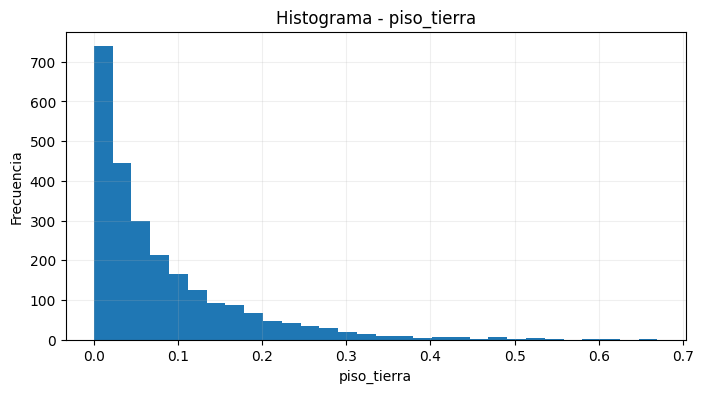

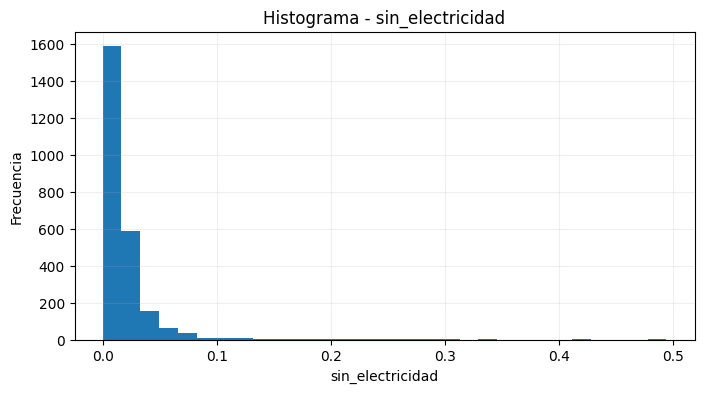

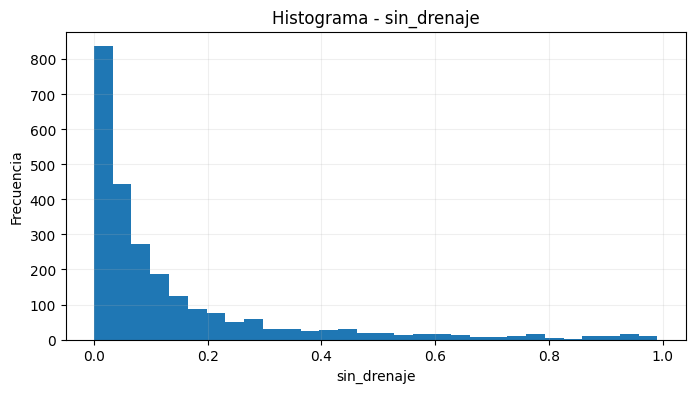

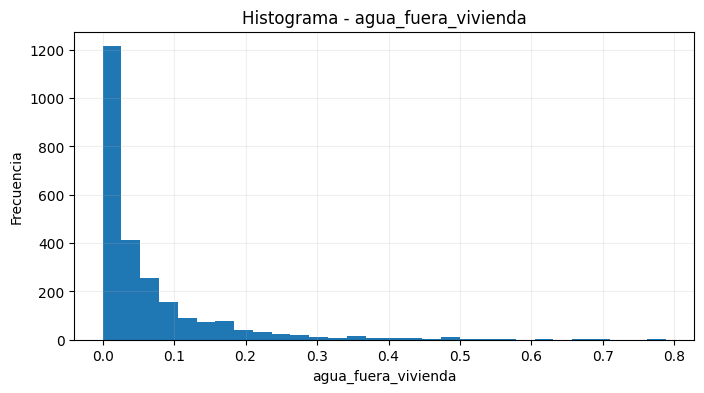

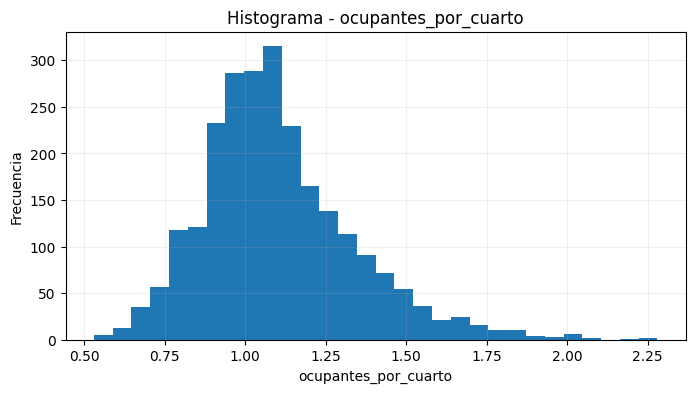

In [28]:
# 12. Histograma por indicador
# ---------------------------
for col in indicadores.columns:
    plt.figure(figsize=(8, 4))
    plt.hist(indicadores[col].dropna(), bins=30)
    plt.title(f"Histograma - {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.2)
    plt.show()


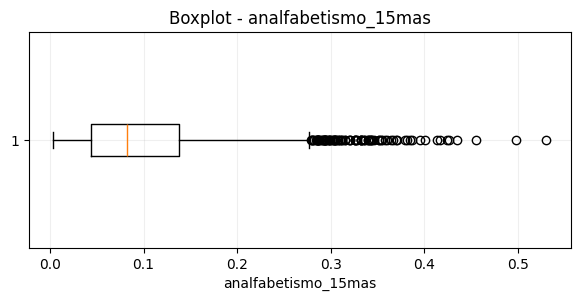

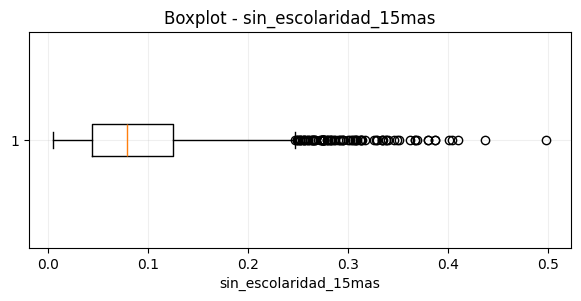

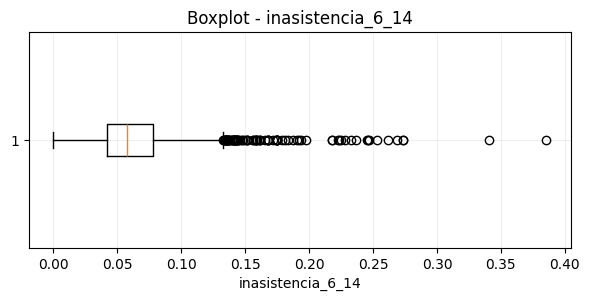

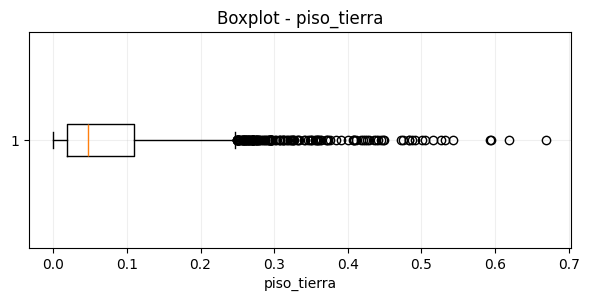

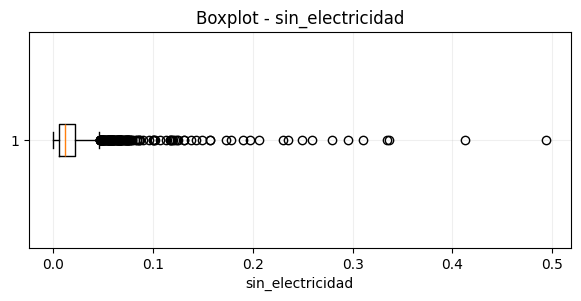

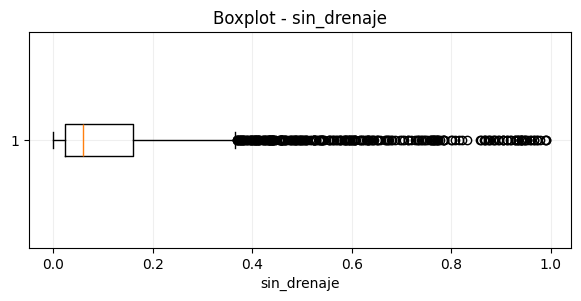

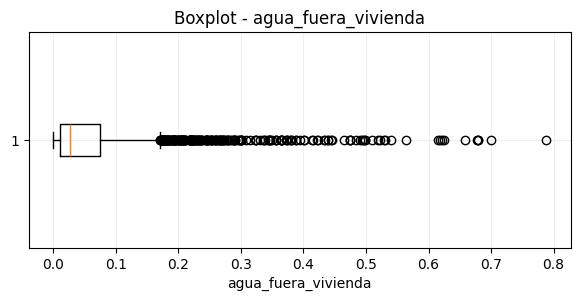

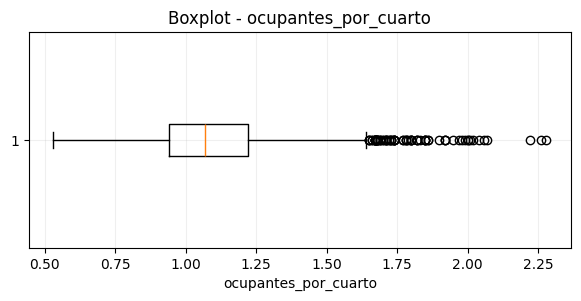

In [30]:
# 13. Boxplot por indicador
# ---------------------------
for col in indicadores.columns:
    plt.figure(figsize=(7, 2.8))
    plt.boxplot(indicadores[col].dropna(), vert=False)
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.grid(alpha=0.2)
    plt.show()



Matriz de correlación:


,analfabetismo_15mas,sin_escolaridad_15mas,inasistencia_6_14,piso_tierra,sin_electricidad,sin_drenaje,agua_fuera_vivienda,ocupantes_por_cuarto
analfabetismo_15mas,1.000000,0.963524,0.312614,0.651080,0.379178,0.525044,0.369848,0.603983
sin_escolaridad_15mas,0.963524,1.000000,0.379561,0.586222,0.376667,0.447230,0.355787,0.576995
inasistencia_6_14,0.312614,0.379561,1.000000,0.169400,0.235557,0.026731,0.111518,0.262189
piso_tierra,0.651080,0.586222,0.169400,1.000000,0.510009,0.626928,0.397065,0.560584
sin_electricidad,0.379178,0.376667,0.235557,0.510009,1.000000,0.458181,0.357863,0.301668
sin_drenaje,0.525044,0.447230,0.026731,0.626928,0.458181,1.000000,0.421311,0.385710
agua_fuera_vivienda,0.369848,0.355787,0.111518,0.397065,0.357863,0.421311,1.000000,0.301664
ocupantes_por_cuarto,0.603983,0.576995,0.262189,0.560584,0.301668,0.385710,0.301664,1.000000


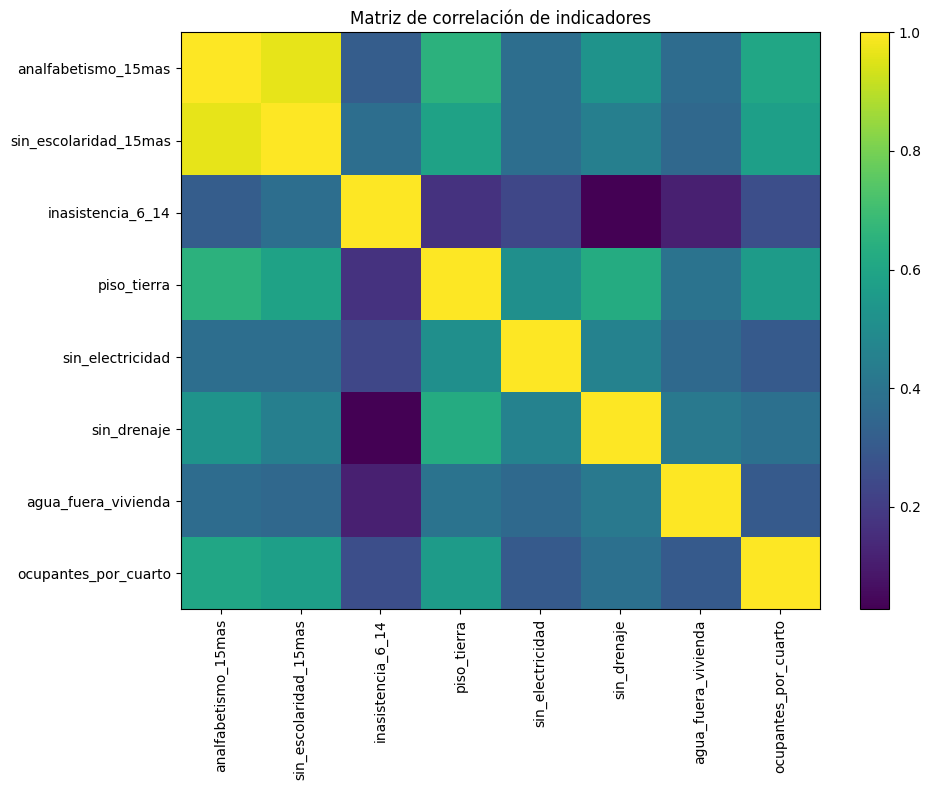

In [31]:
# 14. Correlación entre indicadores
# ---------------------------
corr = indicadores.corr(numeric_only=True)

print("\nMatriz de correlación:")
display(corr)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Matriz de correlación de indicadores")
plt.tight_layout()
plt.show()


In [32]:
# 15. Unir identificadores con indicadores
# ---------------------------
cols_nombre = [c for c in ["NOM_ENT", "NOM_MUN"] if c in df_mun.columns]

resultado_eda = pd.concat(
    [df_mun[cols_nombre].reset_index(drop=True), indicadores.reset_index(drop=True)],
    axis=1
)

print("\nVista final del dataset EDA:")
display(resultado_eda.head())



Vista final del dataset EDA:


,NOM_ENT,NOM_MUN,analfabetismo_15mas,sin_escolaridad_15mas,inasistencia_6_14,piso_tierra,sin_electricidad,sin_drenaje,agua_fuera_vivienda,ocupantes_por_cuarto
0,Aguascalientes,Aguascalientes,0.016422,0.020603,0.046011,0.005735,0.001642,0.002991,0.003707,0.84
1,Aguascalientes,Asientos,0.035234,0.034695,0.062949,0.014671,0.007575,0.035640,0.009887,1.07
2,Aguascalientes,Calvillo,0.044873,0.050946,0.069485,0.011193,0.007204,0.006625,0.009391,0.97
3,Aguascalientes,Cosío,0.031395,0.030295,0.056976,0.010160,0.006350,0.011938,0.007874,1.14
4,Aguascalientes,Jesús María,0.023774,0.028343,0.058776,0.012374,0.004667,0.007798,0.008611,0.95


In [33]:
# 16. Top municipios extremos por indicador
# ---------------------------
for col in indicadores.columns:
    print(f"\n========== TOP 10 MAYORES: {col} ==========")
    top = resultado_eda[cols_nombre + [col]].sort_values(col, ascending=False).head(10)
    display(top)

    print(f"\n========== TOP 10 MENORES: {col} ==========")
    bottom = resultado_eda[cols_nombre + [col]].sort_values(col, ascending=True).head(10)
    display(bottom)


========== TOP 10 MAYORES: analfabetismo_15mas ==========


,NOM_ENT,NOM_MUN,analfabetismo_15mas
451,Guerrero,Cochoapa el Grande,0.530573
1404,Oaxaca,Santa María la Asunción,0.497793
213,Chihuahua,Batopilas de Manuel Gómez Morín,0.455032
1505,Oaxaca,Santiago Yaitepec,0.435134
1024,Oaxaca,Coicoyán de las Flores,0.426911
1284,Oaxaca,San Miguel Santa Flor,0.424242
1250,Oaxaca,San Martín Peras,0.416644
2202,Veracruz de Ignacio de la Llave,Mixtla de Altamirano,0.413957
163,Chiapas,Sitalá,0.400818
435,Guerrero,Tlacoachistlahuaca,0.395783



========== TOP 10 MENORES: analfabetismo_15mas ==========


,NOM_ENT,NOM_MUN,analfabetismo_15mas
285,Ciudad de México,Benito Juárez,0.003526
683,México,Coacalco de Berriozábal,0.007305
963,Nuevo León,Apodaca,0.007336
287,Ciudad de México,Miguel Hidalgo,0.007508
1919,Sonora,Cananea,0.008857
286,Ciudad de México,Cuauhtémoc,0.009499
1003,Nuevo León,San Nicolás de los Garza,0.009543
687,México,Cuautitlán,0.009836
1943,Sonora,Nogales,0.009919
976,Nuevo León,San Pedro Garza García,0.009945



========== TOP 10 MAYORES: sin_escolaridad_15mas ==========


...

,NOM_ENT,NOM_MUN,agua_fuera_vivienda
1202,Oaxaca,San Juan del Río,0.0
1199,Oaxaca,San Juan Chicomezúchil,0.0
1254,Oaxaca,San Mateo Cajonos,0.0
1204,Oaxaca,San Juan Evangelista Analco,0.0
1944,Sonora,Onavas,0.0
1953,Sonora,San Felipe de Jesús,0.0
1934,Sonora,Huépac,0.0
1354,Oaxaca,San Sebastián Nicananduta,0.0
1146,Oaxaca,San Francisco Cajonos,0.0
1159,Oaxaca,San Francisco Teopan,0.0



========== TOP 10 MAYORES: ocupantes_por_cuarto ==========


,NOM_ENT,NOM_MUN,ocupantes_por_cuarto
1360,Oaxaca,San Simón Zahuatlán,2.28
451,Guerrero,Cochoapa el Grande,2.26
2159,Veracruz de Ignacio de la Llave,Filomeno Mata,2.22
1256,Oaxaca,San Mateo del Mar,2.07
2251,Veracruz de Ignacio de la Llave,Tehuipango,2.06
1024,Oaxaca,Coicoyán de las Flores,2.04
452,Guerrero,José Joaquín de Herrera,2.02
178,Chiapas,Totolapa,2.01
105,Chiapas,Chanal,2.00
2323,Yucatán,Chemax,2.00



========== TOP 10 MENORES: ocupantes_por_cuarto ==========


,NOM_ENT,NOM_MUN,ocupantes_por_cuarto
227,Chihuahua,Dr. Belisario Domínguez,0.53
2003,Tamaulipas,Guerrero,0.55
2013,Tamaulipas,Mier,0.55
285,Ciudad de México,Benito Juárez,0.56
1957,Sonora,San Pedro de la Cueva,0.58
231,Chihuahua,Gran Morelos,0.59
1928,Sonora,Granados,0.59
1968,Sonora,Villa Pesqueira,0.60
960,Nuevo León,Los Aldamas,0.60
2014,Tamaulipas,Miguel Alemán,0.61


In [34]:
# 17. Resumen breve del EDA
# ---------------------------
print("\nRESUMEN DEL EDA")
print("- Se filtró el dataset al nivel municipal.")
print("- Se construyeron indicadores relativos de educación, vivienda y servicios.")
print("- Se revisaron faltantes, distribuciones y valores extremos.")
print("- Las variables están en escalas distintas, por lo que para PCA después conviene estandarizarlas.")
print("- La correlación entre varios indicadores puede justificar una técnica de reducción de dimensionalidad como PCA.")


RESUMEN DEL EDA
- Se filtró el dataset al nivel municipal.
- Se construyeron indicadores relativos de educación, vivienda y servicios.
- Se revisaron faltantes, distribuciones y valores extremos.
- Las variables están en escalas distintas, por lo que para PCA después conviene estandarizarlas.
- La correlación entre varios indicadores puede justificar una técnica de reducción de dimensionalidad como PCA.


/tmp/ipykernel_767/2133153885.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["indice_raw"] = coords[:, 0]
/tmp/ipykernel_767/2133153885.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["indice_marginacion"] = 100 * (


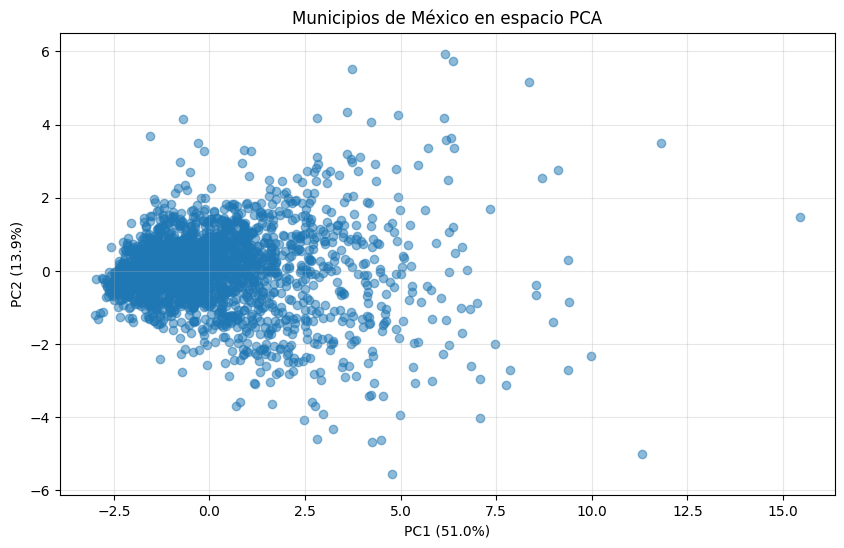

                                NOM_ENT                          NOM_MUN  \
41015                         Chihuahua  Batopilas de Manuel Gómez Morín   
74601                          Guerrero               Cochoapa el Grande   
55115                           Durango                        Mezquital   
107184                          Nayarit                        Del Nayar   
183263  Veracruz de Ignacio de la Llave                       Tehuipango   
22172                           Chiapas                    Chalchihuitán   
118019                           Oaxaca                 San José Tenango   
32885                           Chiapas                           Sitalá   
84722                           Jalisco                        Mezquitic   
114707                           Oaxaca           Coicoyán de las Flores   

        indice_marginacion  
41015           100.000000  
74601            80.301772  
55115            77.600762  
107184           70.379104  
183263           6

In [10]:


# 1. Cargar datos
#df = pd.read_csv("conjunto_de_datos_iter_00CSV20.csv", low_memory=False)

# 2. Filtrar nivel municipal
df = df[(df["MUN"] > 0) & (df["LOC"] == 0)].copy()

# 3. Limpieza
for c in df.columns:
    if c not in ["NOM_ENT", "NOM_MUN", "NOM_LOC", "LONGITUD", "LATITUD", "ALTITUD", "TAMLOC"]:
        df[c] = pd.to_numeric(df[c].replace({"*": np.nan, "N/D": np.nan}), errors="coerce")

# 4. Construcción de indicadores
ind = pd.DataFrame({
    "analfabetismo_15mas": df["P15YM_AN"] / df["P_15YMAS"].replace(0, np.nan),
    "sin_escolaridad_15mas": df["P15YM_SE"] / df["P_15YMAS"].replace(0, np.nan),
    "inasistencia_6_14": (df["P6A11_NOA"] + df["P12A14NOA"]) / (df["P_6A11"] + df["P_12A14"]).replace(0, np.nan),
    "piso_tierra": df["VPH_PISOTI"] / df["TVIVPARHAB"].replace(0, np.nan),
    "sin_electricidad": df["VPH_S_ELEC"] / df["TVIVPARHAB"].replace(0, np.nan),
    "sin_drenaje": df["VPH_NODREN"] / df["TVIVPARHAB"].replace(0, np.nan),
    "agua_fuera_vivienda": df["VPH_AGUAFV"] / df["TVIVPARHAB"].replace(0, np.nan),
    "ocupantes_por_cuarto": df["PRO_OCUP_C"]
}).fillna(0)

# 5. Estandarizar
X = StandardScaler().fit_transform(ind)

# 6. PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# 7. Índice
df["indice_raw"] = coords[:, 0]
df["indice_marginacion"] = 100 * (
    (df["indice_raw"] - df["indice_raw"].min()) /
    (df["indice_raw"].max() - df["indice_raw"].min())
)

# 8. Gráfica
plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Municipios de México en espacio PCA")
plt.grid(True, alpha=0.3)
plt.show()

# 9. Ranking
resultado = df[["NOM_ENT", "NOM_MUN", "indice_marginacion"]].sort_values(
    "indice_marginacion", ascending=False
)
print(resultado.head(10))
print(resultado.tail(10))

Municipios: (2469, 286)


/tmp/ipykernel_767/2180585567.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c] = df[c].replace(["*", "N/D", "ND"], np.nan)


Indicadores: (2469, 8)
Varianza explicada:
[0.51000285 0.13942517 0.10426013 0.08303871 0.06588639 0.05446668
 0.03931983 0.00360024]
Varianza PC1: 0.5100028469998459
Varianza PC2: 0.1394251670272892


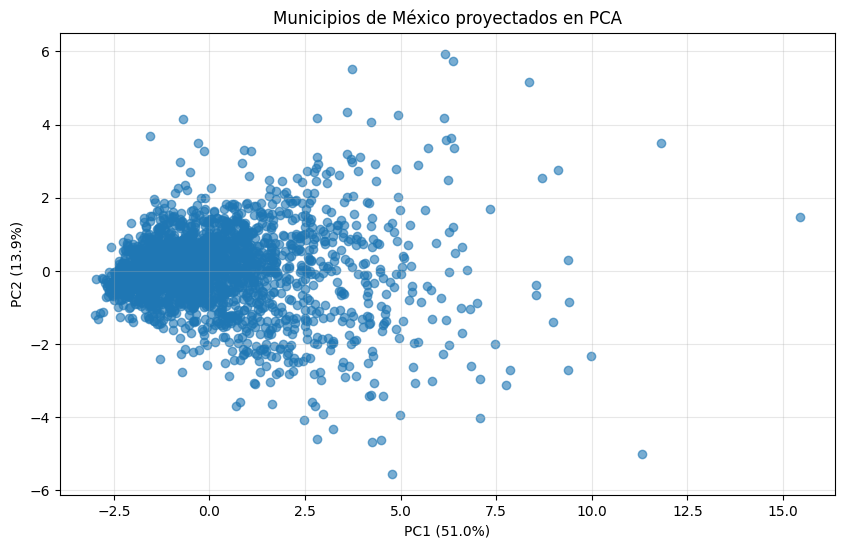


Municipios con mayor marginalidad:
                                NOM_ENT                          NOM_MUN  indice_marginacion
41015                         Chihuahua  Batopilas de Manuel Gómez Morín          100.000000
74601                          Guerrero               Cochoapa el Grande           80.301772
55115                           Durango                        Mezquital           77.600762
107184                          Nayarit                        Del Nayar           70.379104
183263  Veracruz de Ignacio de la Llave                       Tehuipango           67.207377
22172                           Chiapas                    Chalchihuitán           67.169170
118019                           Oaxaca                 San José Tenango           67.133520
32885                           Chiapas                           Sitalá           65.659183
84722                           Jalisco                        Mezquitic           64.958881
114707                           O

/tmp/ipykernel_767/2180585567.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["indice_raw"] = coords[:,0]
/tmp/ipykernel_767/2180585567.py:128: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["indice_marginacion"] = (


In [35]:
# =====================================================
# PCA + Índice de Marginalidad Municipal
# =====================================================



#from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------------
# 1. Cargar dataset
# -----------------------------------

#ruta_csv = "conjunto_de_datos_iter_00CSV20.csv"

#df = pd.read_csv(ruta_csv, low_memory=False)

# -----------------------------------
# 2. Filtrar nivel municipal
# -----------------------------------

df["MUN"] = pd.to_numeric(df["MUN"], errors="coerce")
df["LOC"] = pd.to_numeric(df["LOC"], errors="coerce")

df = df[(df["MUN"] > 0) & (df["LOC"] == 0)].copy()

print("Municipios:", df.shape)

# -----------------------------------
# 3. Limpieza básica
# -----------------------------------

for c in df.columns:
    df[c] = df[c].replace(["*", "N/D", "ND"], np.nan)

for c in df.columns:
    try:
        df[c] = pd.to_numeric(df[c])
    except:
        pass

# -----------------------------------
# 4. Construcción de indicadores
# -----------------------------------

def safe_div(num, den):
    return num / den.replace(0, np.nan)

indicadores = pd.DataFrame()

indicadores["analfabetismo"] = safe_div(df["P15YM_AN"], df["P_15YMAS"])
indicadores["sin_escolaridad"] = safe_div(df["P15YM_SE"], df["P_15YMAS"])
indicadores["inasistencia_escolar"] = safe_div(
    df["P6A11_NOA"] + df["P12A14NOA"],
    df["P_6A11"] + df["P_12A14"]
)

indicadores["piso_tierra"] = safe_div(df["VPH_PISOTI"], df["TVIVPARHAB"])
indicadores["sin_electricidad"] = safe_div(df["VPH_S_ELEC"], df["TVIVPARHAB"])
indicadores["sin_drenaje"] = safe_div(df["VPH_NODREN"], df["TVIVPARHAB"])
indicadores["agua_fuera"] = safe_div(df["VPH_AGUAFV"], df["TVIVPARHAB"])

indicadores["ocupantes_cuarto"] = df["PRO_OCUP_C"]

indicadores = indicadores.fillna(0)

print("Indicadores:", indicadores.shape)

# -----------------------------------
# 5. Estandarización
# -----------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(indicadores)

# -----------------------------------
# 6. PCA
# -----------------------------------

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada:")
print(pca.explained_variance_ratio_)

# -----------------------------------
# 7. PCA 2 dimensiones
# -----------------------------------

pca2 = PCA(n_components=2)

coords = pca2.fit_transform(X_scaled)

print("Varianza PC1:", pca2.explained_variance_ratio_[0])
print("Varianza PC2:", pca2.explained_variance_ratio_[1])

# -----------------------------------
# 8. Gráfica 2D
# -----------------------------------

plt.figure(figsize=(10,6))

plt.scatter(
    coords[:,0],
    coords[:,1],
    alpha=0.6
)

plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")

plt.title("Municipios de México proyectados en PCA")

plt.grid(alpha=0.3)

plt.show()

# -----------------------------------
# 9. Índice de marginalidad
# -----------------------------------

df["indice_raw"] = coords[:,0]

# normalización 0-100

df["indice_marginacion"] = (
    (df["indice_raw"] - df["indice_raw"].min()) /
    (df["indice_raw"].max() - df["indice_raw"].min())
) * 100

# -----------------------------------
# 10. Ranking municipios
# -----------------------------------

ranking = df[[
    "NOM_ENT",
    "NOM_MUN",
    "indice_marginacion"
]].sort_values(
    "indice_marginacion",
    ascending=False
)

print("\nMunicipios con mayor marginalidad:")
print(ranking.head(15))

print("\nMunicipios con menor marginalidad:")
print(ranking.tail(15))

# -----------------------------------
# 11. Guardar resultados
# -----------------------------------

ranking.to_csv("indice_marginacion_municipal.csv", index=False)

print("\nArchivo guardado: indice_marginacion_municipal.csv")

In [37]:
ranking.head(15)

,NOM_ENT,NOM_MUN,indice_marginacion
41015,Chihuahua,Batopilas de Manuel Gómez Morín,100.000000
74601,Guerrero,Cochoapa el Grande,80.301772
55115,Durango,Mezquital,77.600762
107184,Nayarit,Del Nayar,70.379104
183263,Veracruz de Ignacio de la Llave,Tehuipango,67.207377
22172,Chiapas,Chalchihuitán,67.169170
118019,Oaxaca,San José Tenango,67.133520
32885,Chiapas,Sitalá,65.659183
84722,Jalisco,Mezquitic,64.958881
114707,Oaxaca,Coicoyán de las Flores,63.421120
